# Supplementary Figure S7 — subunit-resolved experimental Kv2.1 L403A signatures

This analysis compares chain-resolved conformational changes between experimental WT and L403A Kv2.1 structures with protocol-matched WT-to-L403A changes in the prediction ensembles. Experimental changes are defined as 8SDA − 8SD3. Predicted changes are summarized within complete seeds before bootstrap confidence intervals are calculated, so model parameterizations and recycle snapshots are not treated as independent observations.

Subunits A–D are retained separately because the experimental transition is asymmetric across protomers.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

repo_root = Path.cwd()
if not (repo_root / 'shared').is_dir():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))
from shared.plotting import apply_kv21_style, KV21_PALETTE

TABLE = repo_root / 'kv21/dataExtra/conformation_analysis/tables/protocol_effects_by_metric_subunit.csv'
FIG_DIR = repo_root / 'docs/figures/supplementary_figure_s7'
TAB_DIR = repo_root / 'docs/tables/supplementary_figure_s7'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

effects = pd.read_csv(TABLE)
assert effects.analysis.eq('distance_qc_primary').all()
assert set(effects.canonical_subunit) == set('ABCD')
display(effects.head())

,analysis,canonical_subunit,metric,angular,experimental_delta,absolute_experimental_error__masked,absolute_experimental_error__vanilla,ci_high__masked,ci_high__vanilla,ci_low__masked,...,model_delta__masked,model_delta__vanilla,n_paired_seeds__masked,n_paired_seeds__vanilla,recovery_ratio__masked,recovery_ratio__vanilla,masked_advantage,masked_advantage_ci_low,masked_advantage_ci_high,n_common_seeds
0,distance_qc_primary,A,F412_403_neighbor_ca_distance_A,False,0.333846,0.522388,0.490198,-0.179263,-0.151053,-0.200856,...,-0.188541,-0.156351,100.0,93.0,-0.564755,-0.468334,-0.032190,-0.047446,-0.020572,78
1,distance_qc_primary,A,F412_403_neighbor_shortest_heavy_A,False,-0.218616,0.153354,0.116720,-0.058284,-0.095154,-0.070710,...,-0.065262,-0.101895,100.0,93.0,0.298523,0.466093,-0.036633,-0.048957,-0.027848,78
2,distance_qc_primary,A,F412_L316_same_ca_distance_A,False,-0.014294,0.213143,0.314363,-0.219869,-0.319058,-0.241948,...,-0.227437,-0.328657,100.0,93.0,15.911030,22.992168,0.101220,0.080786,0.111777,78
3,distance_qc_primary,A,F412_L316_same_shortest_heavy_A,False,-0.302245,0.241170,0.154313,-0.058071,-0.141061,-0.070012,...,-0.061075,-0.147932,100.0,93.0,0.202072,0.489445,-0.086857,-0.095027,-0.077335,78
4,distance_qc_primary,A,F412_L329_neighbor_ca_distance_A,False,0.452234,0.496050,0.497411,-0.034249,-0.038995,-0.060248,...,-0.043816,-0.045177,100.0,93.0,-0.096888,-0.099897,0.001361,-0.016688,0.016817,78


## Quantities and statistical interpretation

For every metric and subunit, the experimental marker is Δexp = 8SDA − 8SD3. Vanilla and masked points are the median protocol-matched WT→L403A seed effect; vertical intervals are the 95% complete-seed bootstrap confidence intervals.

Most detailed panels show the **fraction of the experimental change recovered**, Δprediction/Δexperiment. The experimental target is therefore 1, zero means no predicted WT→L403A response, and negative values indicate movement opposite to experiment. I405 pore-facing orientation is shown in raw score-change units because the experimental subunit-C change is near zero and would make a recovery ratio unstable. Exact physical-unit changes remain available in the source and exported tables.

The overview heatmap uses **normalized experimental-target error**:

`|Δprediction − Δexperiment| / (|Δprediction| + |Δexperiment|)`

with circular error for angular metrics. It is bounded from 0 (exact recovery) to 1 (no recovery or opposing change). This normalization is used only for the cross-metric color scale; detailed panels remain in their physical units.

In [2]:
apply_kv21_style()
VAN = KV21_PALETTE['L403A_VAN']
MASK = KV21_PALETTE['L403A_HM']
EXP = '#222222'
SUBUNITS = list('ABCD')

LABELS = {
    'kink_angle_deg': 'PIP/S6 kink angle (°)',
    'whole_s6_rotation_vs_8SD3_deg': 'Whole-S6 rotation (°)',
    'I401_azimuth_deg': 'I401 azimuth (°)',
    'I405_azimuth_deg': 'I405 azimuth (°)',
    'I401_pore_facing_score': 'I401 pore-facing score',
    'I405_pore_facing_score': 'I405 pore-facing score',
    'linker_radial_distance_A': 'S4–S5 radial position (Å)',
    'linker_residue_ca_displacement_max_A': 'Maximum linker Cα displacement (Å)',
    'F412_sidechain_centroid_displacement_vs_8SD3_A': 'F412 side-chain displacement (Å)',
    'F412_L316_same_shortest_heavy_A': 'F412–L316 contact (Å)',
    'F412_L329_neighbor_shortest_heavy_A': 'F412–L329 contact (Å)',
    'F412_403_neighbor_shortest_heavy_A': 'F412–403 neighbor contact (Å)',
}

def effect_panel(ax, metric, title=None, ylabel=None, normalize=True):
    z = effects[effects.metric.eq(metric)].set_index('canonical_subunit').reindex(SUBUNITS)
    exp_delta = z.experimental_delta.to_numpy(float)
    x = np.arange(4); offsets = {'vanilla': -.16, 'masked': .16}
    for protocol, color in [('vanilla', VAN), ('masked', MASK)]:
        scale = exp_delta if normalize else np.ones_like(exp_delta)
        y = z[f'model_delta__{protocol}'].to_numpy(float) / scale
        a = z[f'ci_low__{protocol}'].to_numpy(float) / scale
        b = z[f'ci_high__{protocol}'].to_numpy(float) / scale
        lo, hi = np.minimum(a, b), np.maximum(a, b)
        ax.errorbar(x + offsets[protocol], y, yerr=[y-lo, hi-y], fmt='o', ms=6.5,
                    color=color, ecolor=color, elinewidth=1.4, capsize=2.5, zorder=3)
    target = np.ones(4) if normalize else exp_delta
    ax.scatter(x, target, marker='D', s=45, facecolor='white',
               edgecolor=EXP, linewidth=1.5, zorder=4)
    ax.axhline(0, color='#777777', lw=.8, ls='--')
    ax.set_xticks(x, SUBUNITS, rotation=0, ha='center')
    ax.set_title(title or LABELS.get(metric, metric), fontsize=12.5, fontweight='semibold', pad=9)
    default_ylabel = 'Fraction of experimental change' if normalize else 'WT→L403A change'
    ax.set_ylabel(ylabel or default_ylabel, fontsize=11.5)
    ax.tick_params(labelsize=10.5)
    sns.despine(ax=ax)

legend_handles = [
    Line2D([0],[0], marker='D', color='none', markerfacecolor='white', markeredgecolor=EXP,
           markeredgewidth=1.4, markersize=7, label='Experiment: 8SD3→8SDA'),
    Line2D([0],[0], marker='o', color=VAN, markersize=7, label='Vanilla: WT→L403A'),
    Line2D([0],[0], marker='o', color=MASK, markersize=7, label='Targeted masking: WT→L403A'),
]

In [3]:
# Subunit-resolved conformational metrics included in the comparative analysis.
heat_metrics = [
    'kink_angle_deg', 'whole_s6_rotation_vs_8SD3_deg',
    'I401_azimuth_deg', 'I405_azimuth_deg',
    'I401_pore_facing_score', 'I405_pore_facing_score',
    'linker_radial_distance_A', 'linker_residue_ca_displacement_max_A',
    'F412_sidechain_centroid_displacement_vs_8SD3_A',
    'F412_L316_same_shortest_heavy_A', 'F412_L329_neighbor_shortest_heavy_A',
    'F412_403_neighbor_shortest_heavy_A',
]

heat_rows = []
for metric in heat_metrics:
    for subunit in SUBUNITS:
        r = effects[(effects.metric == metric) & (effects.canonical_subunit == subunit)].iloc[0]
        for protocol in ['vanilla', 'masked']:
            pred = float(r[f'model_delta__{protocol}'])
            exp = float(r.experimental_delta)
            raw_error = float(r[f'absolute_experimental_error__{protocol}'])
            denom = abs(pred) + abs(exp)
            normalized_error = raw_error / denom if denom > 1e-12 else 0.0
            normalized_error = min(1.0, normalized_error)
            heat_rows.append(dict(metric=metric, subunit=subunit, protocol=protocol,
                                  predicted_delta=pred, experimental_delta=exp,
                                  absolute_error=raw_error, normalized_error=normalized_error))
heat = pd.DataFrame(heat_rows)
heat.to_csv(TAB_DIR / 'subunit_resolved_experimental_target_error.csv', index=False)

# Trajectory-balanced E423–N179 occupancy. Each independent model–seed
# trajectory contributes one within-trajectory shifted-snapshot fraction.
shift_source = pd.read_csv(repo_root / 'kv21/dataDistances/analysis/L403A_E423_N179_all_structure_distances.csv')
shift_columns = [f'CA_CA_{s}_GLU425_CA-{s}_ASN181_CA' for s in 'ABCD']
shift_source['model'] = pd.to_numeric(shift_source.pdb_file.str.extract(r'_model_(\d+)', expand=False))
shift_source['seed'] = pd.to_numeric(shift_source.pdb_file.str.extract(r'_seed_(\d+)', expand=False))
shift_source['any_shifted'] = shift_source[shift_columns].ge(12.84).any(axis=1).astype(float)
trajectory_shift = (shift_source.groupby(['condition','model','seed'], as_index=False)
                    .any_shifted.mean().rename(columns={'condition':'Protocol'}))
rng = np.random.default_rng(20260819)
occupancy_rows = []
for protocol, part in trajectory_shift.groupby('Protocol'):
    values = part.any_shifted.to_numpy(float)
    boots = np.array([rng.choice(values, len(values), replace=True).mean() for _ in range(10000)])
    occupancy_rows.append({
        'Protocol': protocol,
        'trajectory_balanced_fraction': values.mean(),
        'ci_low': np.quantile(boots, .025),
        'ci_high': np.quantile(boots, .975),
        'independent_model_seed_trajectories': len(values),
        'threshold_A': 12.84,
        'bootstrap_replicates': 10000,
    })
occupancy_summary = pd.DataFrame(occupancy_rows)
occupancy_summary.to_csv(TAB_DIR / 'e423_n179_trajectory_balanced_occupancy.csv', index=False)

matrix = heat.assign(column=heat.subunit + '\n' + heat.protocol.str.title())             .pivot(index='metric', columns='column', values='normalized_error')             .reindex(index=heat_metrics, columns=[f'{s}\n{p}' for s in SUBUNITS for p in ['Vanilla','Masked']])
matrix.index = [LABELS[m] for m in matrix.index]
matrix

column,A\nVanilla,A\nMasked,B\nVanilla,B\nMasked,C\nVanilla,C\nMasked,D\nVanilla,D\nMasked
PIP/S6 kink angle (°),0.952733,1.000000,0.986051,1.000000,0.960566,1.000000,1.000000,1.000000
Whole-S6 rotation (°),0.846626,0.918762,1.000000,1.000000,0.764172,0.870849,1.000000,1.000000
I401 azimuth (°),0.993837,0.951100,1.000000,1.000000,0.979069,0.844918,1.000000,1.000000
I405 azimuth (°),0.909825,1.000000,1.000000,0.961312,1.000000,0.569676,1.000000,0.969852
I401 pore-facing score,0.993145,0.975804,1.000000,1.000000,0.957737,0.938736,1.000000,1.000000
I405 pore-facing score,0.873703,1.000000,1.000000,0.947941,1.000000,0.139255,1.000000,0.947133
S4–S5 radial position (Å),0.677766,0.921161,0.811464,0.971211,0.440214,0.783545,0.884570,0.978051
Maximum linker Cα displacement (Å),0.899272,1.000000,0.895012,1.000000,0.868801,1.000000,0.952789,1.000000
F412 side-chain displacement (Å),1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
F412–L316 contact (Å),0.342782,0.663793,0.655129,0.838828,0.157944,0.529366,0.521238,0.762371


findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


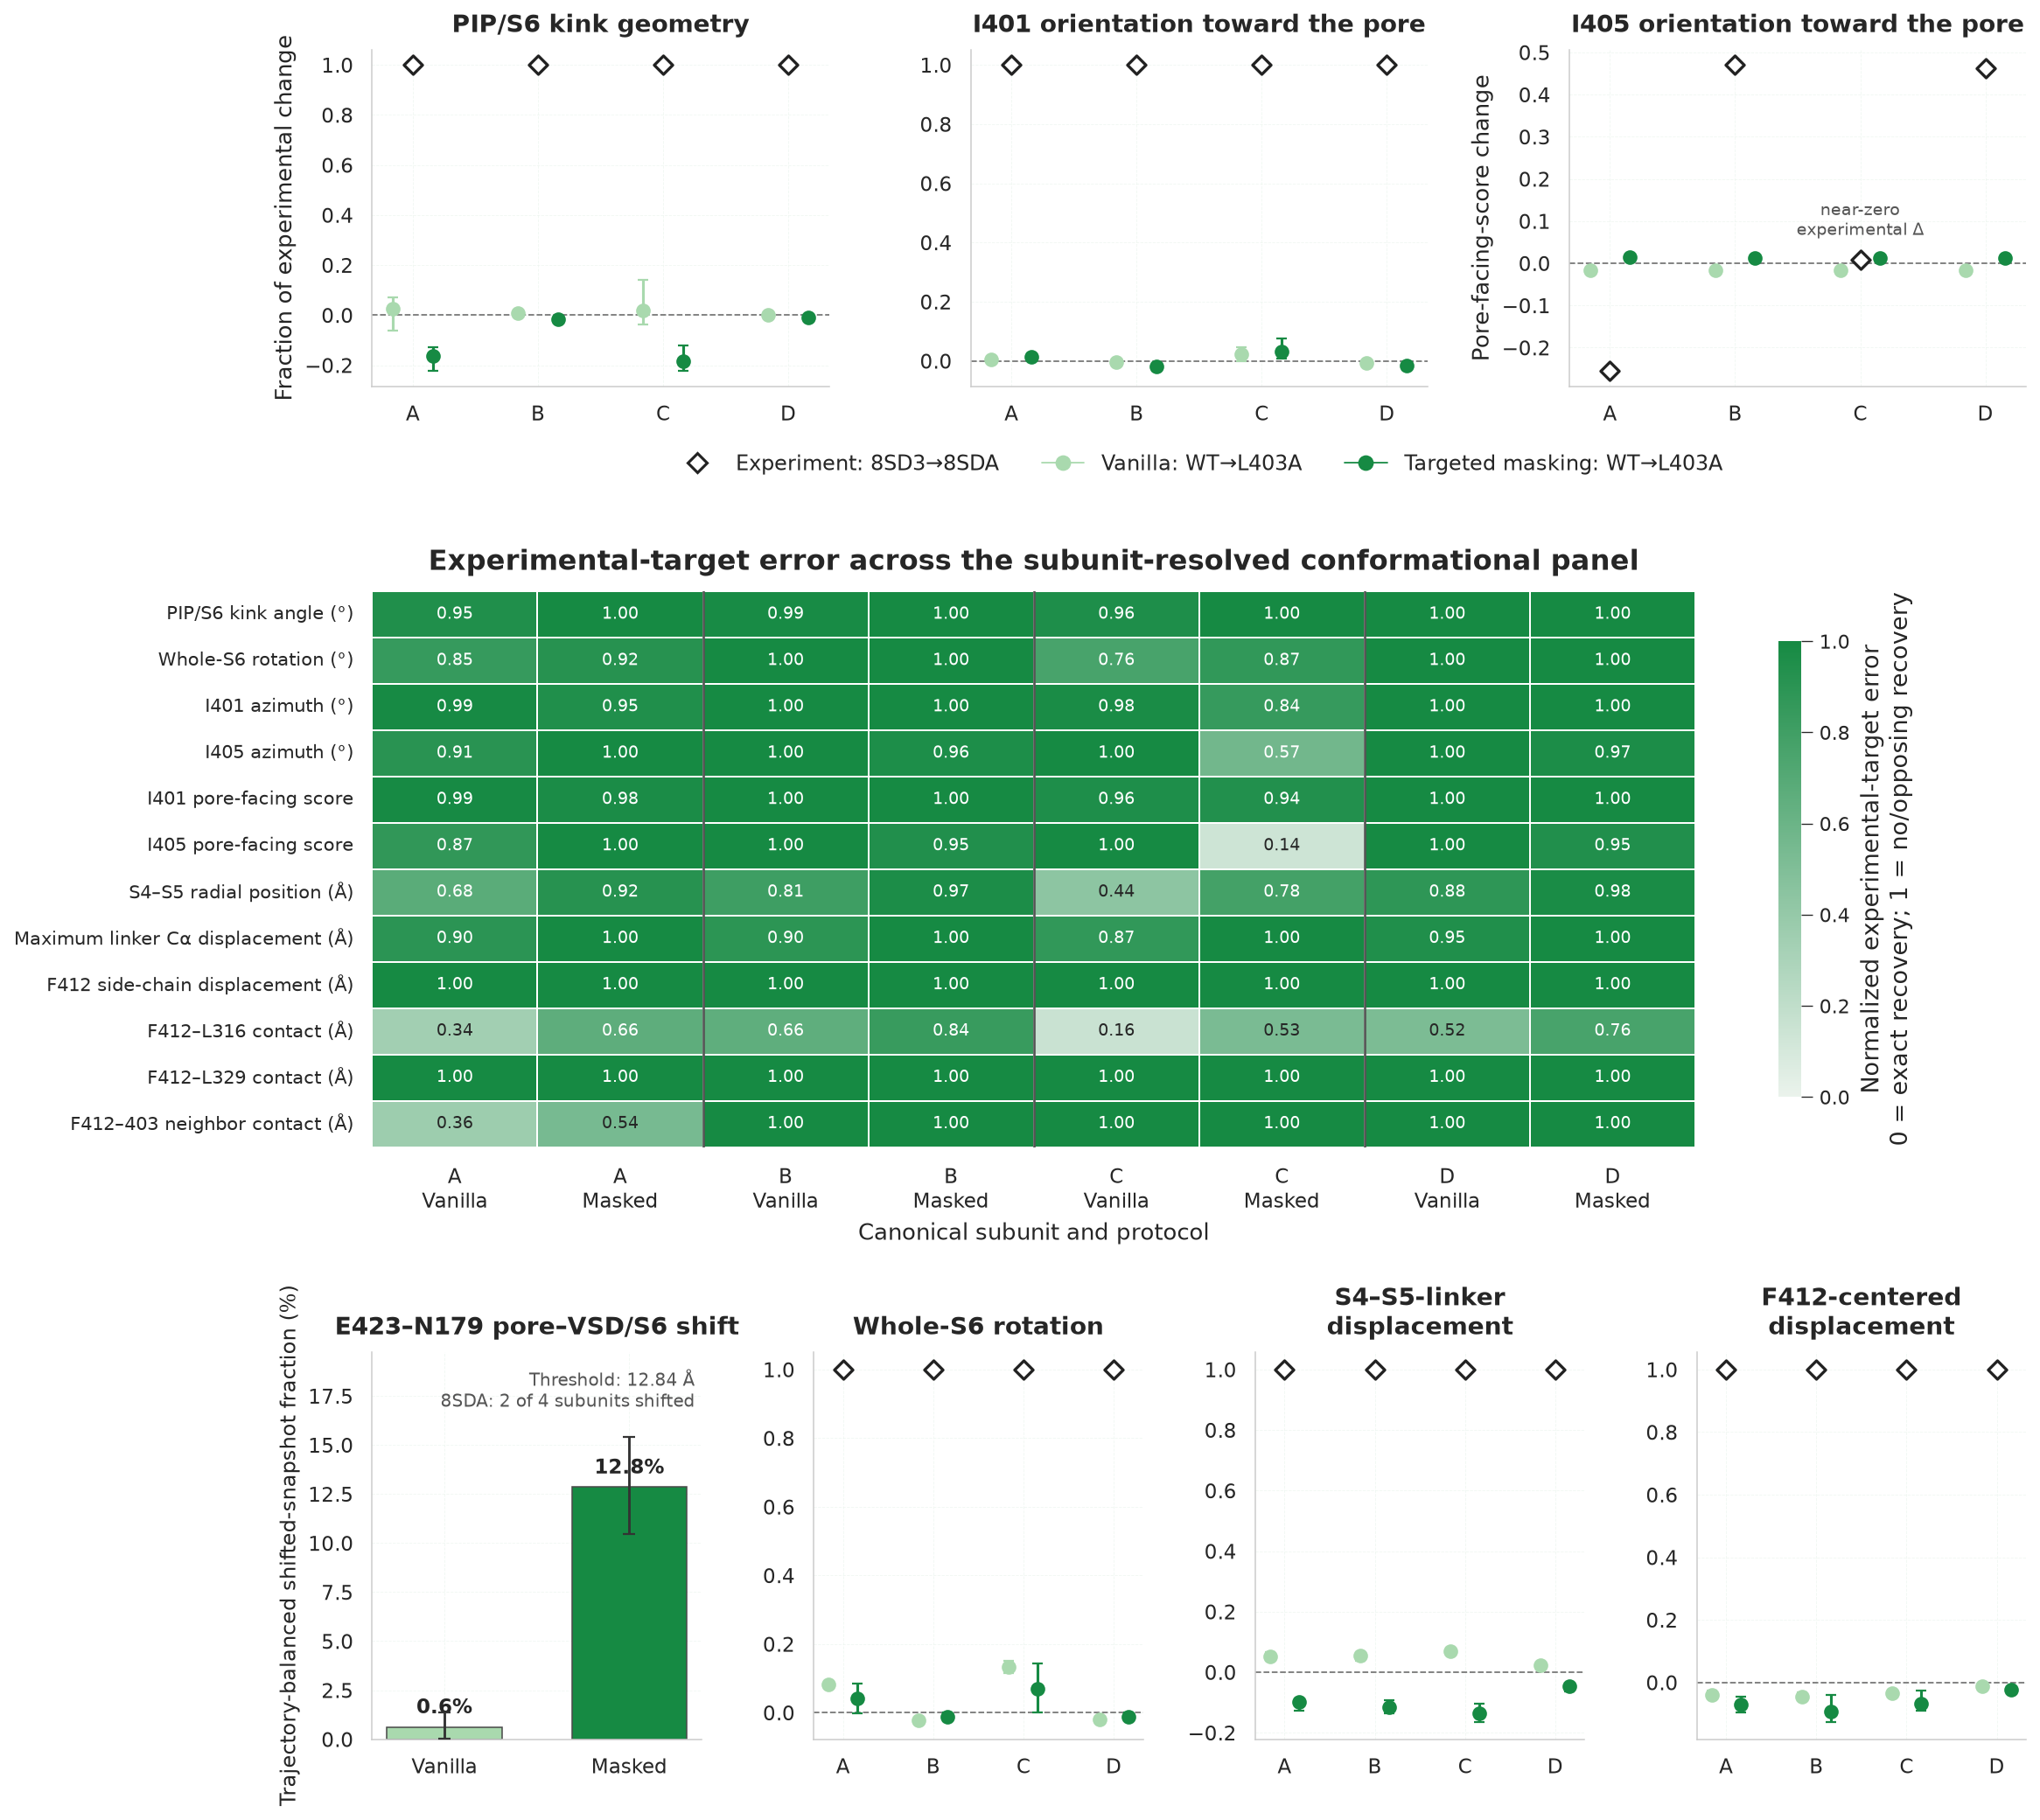

Saved: docs/figures/supplementary_figure_s7/Figure_S7_Kv21_L403A_subunit_resolved_experimental_signatures.png
Saved: docs/figures/supplementary_figure_s7/Figure_S7_Kv21_L403A_subunit_resolved_experimental_signatures.pdf


In [4]:
fig = plt.figure(figsize=(14.5, 13.8), facecolor='white')
outer = fig.add_gridspec(3, 1, height_ratios=[1.0, 1.65, 1.15], hspace=.48)
fig.subplots_adjust(left=.16, right=.975, top=.94, bottom=.065)

# Primary experimental signatures.
top = outer[0].subgridspec(1, 3, wspace=.31)
ax_kink = fig.add_subplot(top[0, 0])
ax_i401 = fig.add_subplot(top[0, 1])
ax_i405 = fig.add_subplot(top[0, 2])
effect_panel(ax_kink, 'kink_angle_deg', 'PIP/S6 kink geometry')
effect_panel(ax_i401, 'I401_pore_facing_score', 'I401 orientation toward the pore')
effect_panel(ax_i405, 'I405_pore_facing_score', 'I405 orientation toward the pore',
             ylabel='Pore-facing-score change', normalize=False)
ax_i401.set_ylabel('')
ax_i405.text(2, effects.query("metric == 'I405_pore_facing_score' and canonical_subunit == 'C'").experimental_delta.iloc[0] + .045,
             'near-zero\nexperimental Δ', ha='center', va='bottom', fontsize=8.5, color='#555555')
top_box = outer[0].get_position(fig)
fig.legend(handles=legend_handles, loc='upper center',
           bbox_to_anchor=((top_box.x0 + top_box.x1) / 2, top_box.y0 - .025),
           ncol=3, frameon=False, fontsize=11)

# Complete cross-metric overview.
ax_heat = fig.add_subplot(outer[1])
sns.heatmap(matrix, cmap=sns.light_palette(MASK, as_cmap=True), vmin=0, vmax=1,
            linewidths=.7, linecolor='white', annot=True, fmt='.2f',
            annot_kws={'fontsize': 8.5}, cbar_kws={'label':'Normalized experimental-target error\n0 = exact recovery; 1 = no/opposing recovery', 'shrink':.82}, ax=ax_heat)
ax_heat.set_title('Experimental-target error across the subunit-resolved conformational panel',
                  fontsize=14.5, fontweight='semibold', pad=11)
ax_heat.set_xlabel('Canonical subunit and protocol', fontsize=11.5)
ax_heat.set_ylabel('')
ax_heat.tick_params(axis='x', rotation=0, labelsize=10.5)
ax_heat.tick_params(axis='y', rotation=0, labelsize=9.5)
for x in [2,4,6]: ax_heat.axvline(x, color='#555555', lw=1.2)

# Additional structural signatures, including a nonredundant occupancy summary
# of the E423–N179 shift shown as distributions in the main figure.
bottom = outer[2].subgridspec(1, 4, wspace=.34)
bottom_metrics = [
    ('whole_s6_rotation_vs_8SD3_deg', 'Whole-S6 rotation'),
    ('linker_residue_ca_displacement_max_A', 'S4–S5-linker\ndisplacement'),
    ('F412_sidechain_centroid_displacement_vs_8SD3_A', 'F412-centered\ndisplacement'),
]

ax_occ = fig.add_subplot(bottom[0, 0])
occ = occupancy_summary.set_index('Protocol').reindex(['vanilla','masked'])
reached = occ.trajectory_balanced_fraction * 100
lo = occ.ci_low * 100
hi = occ.ci_high * 100
bars = ax_occ.bar([0,1], reached, width=.62, color=[VAN, MASK],
                  edgecolor='#4a4a4a', linewidth=.7)
ax_occ.errorbar([0,1], reached, yerr=[reached-lo, hi-reached], fmt='none',
                ecolor='#333333', elinewidth=1.3, capsize=3, zorder=4)
for bar, value in zip(bars, reached):
    label = f'{value:.2f}%' if value < .1 else f'{value:.1f}%'
    ax_occ.text(bar.get_x()+bar.get_width()/2, value + .45, label,
                ha='center', va='bottom', fontsize=10.5, fontweight='semibold')
ax_occ.set_xticks([0,1], ['Vanilla','Masked'])
ax_occ.set_ylabel('Trajectory-balanced shifted-snapshot fraction (%)', fontsize=10.8)
ax_occ.set_title('E423–N179 pore–VSD/S6 shift', fontsize=12.5, fontweight='semibold', pad=9)
ax_occ.text(.98, .96, 'Threshold: 12.84 Å\n8SDA: 2 of 4 subunits shifted', transform=ax_occ.transAxes,
            ha='right', va='top', fontsize=9, color='#555555')
ax_occ.set_ylim(0, max(16, float(hi.max())*1.28))
ax_occ.tick_params(labelsize=10.5); sns.despine(ax=ax_occ)

for j, (metric, title) in enumerate(bottom_metrics, start=1):
    ax = fig.add_subplot(bottom[0, j])
    effect_panel(ax, metric, title)
    ax.set_ylabel('')

png = FIG_DIR / 'Figure_S7_Kv21_L403A_subunit_resolved_experimental_signatures.png'
pdf = FIG_DIR / 'Figure_S7_Kv21_L403A_subunit_resolved_experimental_signatures.pdf'
fig.savefig(png, dpi=400, bbox_inches='tight', facecolor='white')
fig.savefig(pdf, bbox_inches='tight', facecolor='white')
plt.show(); plt.close(fig)
print('Saved:', png.relative_to(repo_root))
print('Saved:', pdf.relative_to(repo_root))

## Interpretation

- Recovery is evaluated from the direction and magnitude of each chain-resolved 8SD3→8SDA change—not proximity to one absolute coordinate.
- Metrics and subunits are structurally correlated and are not independent validation tests.
- Lower target error means closer reproduction of that experimental conformational change; it does not imply greater overall model accuracy.
- The heatmap normalization supports visualization across heterogeneous units. Physical-unit estimates and confidence intervals remain the primary quantitative results.